In [1]:
import lh5
import awkward as ak
import hist
import matplotlib.pyplot as plt
from remage import remage_run
import reboost
from reboost import hpge
from reboost.hpge import surface, psd
from reboost.shape import group
from reboost.math import functions
from reboost.math.stats import gaussian_sample
from reboost.utils import get_remage_detector_uids


In [2]:
import os
import subprocess

# ---- CONFIGURE THIS ----
pixi_executable = "/global/u2/r/ritaferi/.pixi/bin/pixi"
pixi_project_dir = "/global/u2/r/ritaferi/HADES_DATA"
# -------------------------

# Save current working directory
original_dir = os.getcwd()

try:
    # Change to pixi project directory
    os.chdir(pixi_project_dir)
    print(f"Changed to: {os.getcwd()}")

    # Run pixi command using the complete executable path
    result = subprocess.run(
        [pixi_executable, "add", "legend-pygeom-l200"],
        check=True,
        capture_output=True,
        text=True
    )

    print("Pixi command succeeded:")
    print(result.stdout)

except subprocess.CalledProcessError as e:
    print("Pixi command failed.")
    print("Return code:", e.returncode)
    print("STDOUT:")
    print(e.stdout)
    print("STDERR:")
    print(e.stderr)

except FileNotFoundError:
    print(f"Pixi executable not found at: {pixi_executable}")

finally:
    # Always return to original directory
    os.chdir(original_dir)
    print(f"Returned to: {os.getcwd()}")

Changed to: /global/u2/r/ritaferi/HADES_DATA
Pixi command succeeded:

Returned to: /global/u2/r/ritaferi/HADES_DATA


In [3]:
import subprocess

pixi_executable = "/global/u2/r/ritaferi/.pixi/bin/pixi"
pixi_project_dir = "/global/u2/r/ritaferi/HADES_DATA"

result = subprocess.run(
    [
        pixi_executable,
        "run",
        "legend-pygeom-l200",
        "l200.gdml"
    ],
    cwd=pixi_project_dir,
    check=True,
    capture_output=True,
    text=True
)

print("Geometry created successfully.")
print(result.stdout)
print(result.stderr)

Geometry created successfully.




KeyboardInterrupt: 

In [30]:
import os

print(os.getcwd())
print(os.path.isdir("hades-metadata"))

/global/u2/r/ritaferi/HADES_DATA
False


In [37]:
macro_content = [
"/RMG/Manager/Logging/LogLevel summary",
"/RMG/Processes/HadronicPhysics Shielding", # This activates hadronic physics, necessary for the radioactive source
"/RMG/Geometry/RegisterDetectorsFromGDML Germanium",
"/RMG/Geometry/RegisterDetectorsFromGDML Scintillator",
"/RMG/Output/NtupleUseVolumeName true",
"/run/initialize",  
#"/RMG/Output/NtuplePerDetector false", # We want it flat for some visualization purposes
"/RMG/Generator/Confine Volume",
"/RMG/Generator/Confinement/Physical/AddVolume .*pen.*", # Confine primaries to all volumes containing "pen"
"/RMG/Generator/Select GPS",
"/gps/particle     ion",
"/gps/ion          92 238", # Simulate U238 this time, i am sure there is a lot of it in PEN
"/gps/energy       0 keV",
"/gps/ang/type     iso",
"/run/beamOn 500", # run 50000 events
]


try:
    # Run remage
    remage_run(macros=macro_content,
              gdml_files="l200.gdml",
              output="out_l200.lh5",
              overwrite_output=True
              )
except Exception as e:
    # Catch any error that remage_run might raise
    print(f"❌ Simulation failed: {e}")

[Summary -> CLHEP::HepRandom seed changed to: 447001817 (from system entropy)


  _ __ ___ _ __ ___   __ _  __ _  ___ 
 | '__/ _ \ '_ ` _ \ / _` |/ _` |/ _ \
 | | |  __/ | | | | | (_| | (_| |  __/ v1.1.0
 |_|  \___|_| |_| |_|\__,_|\__, |\___| using geant4-11-03-patch-02 [MT]
                           |___/      

G4GDML: Reading 'l200.gdml'...
G4GDML: Reading definitions...
G4GDML: Reading materials...
G4GDML: Reading solids...
G4GDML: Reading structure...
G4GDML: Reading userinfo...
G4GDML: Reading setup...
G4GDML: Reading 'l200.gdml' done!
Stripping off GDML names of materials, solids and volumes ...


[Summary -> Checking for overlaps in GDML geometry...
[Summary -> Opening output file: .rmg-tmp-88211.out_l200.hdf5 (for out_l200.lh5)
[Summary -> Starting run nr. 0. Current local time is 21-09-2026 04:24:26 PDT
[Summary -> Number of events to be processed: 500
[Warning -> encountered long global time (> 285.616 yr). Global time precision might be worse than 1 us.
[Summary -> Processing event nr. 50 (10%), at 0 days, 0 hours, 0 minutes and 0 seconds
[Summary -> Processing event nr. 100 (20%), at 0 days, 0 hours, 0 minutes and 0 seconds
[Summary -> Processing event nr. 150 (30%), at 0 days, 0 hours, 0 minutes and 1 seconds
[Summary -> Processing event nr. 200 (40%), at 0 days, 0 hours, 0 minutes and 1 seconds
[Summary -> Processing event nr. 250 (50%), at 0 days, 0 hours, 0 minutes and 2 seconds
[Summary -> Processing event nr. 300 (60%), at 0 days, 0 hours, 0 minutes and 2 seconds
[Summary -> Processing event nr. 350 (70%), at 0 days, 0 hours, 0 minutes and 2 seconds
[Summary -> Proce

In [24]:
# This time we are going to use an additional trick
mapping = reboost.utils.get_remage_detector_uids("out_l200.lh5", lh5_table='stp')
# This gives us a mapping of all of the detectors that were registered by remage.
print(mapping)

{0: 'liquid_argon', 1078400: 'V07302A', 1078405: 'B00002A', 1080000: 'B00089A', 1080001: 'B00091A', 1080002: 'B00091D', 1080003: 'P00537A', 1080004: 'P00538A', 1080005: 'P00573A', 1081600: 'P00661C', 1081601: 'P00662C', 1081602: 'P00664A', 1081603: 'P00665C', 1081604: 'P00748B', 1081605: 'P00909B', 1083200: 'B00091B', 1083201: 'B00000D', 1083202: 'B00002C', 1083203: 'B00032C', 1083204: 'B00032D', 1083205: 'B00035A', 1084800: 'B00035B', 1084801: 'B00061B', 1084802: 'B00089B', 1084803: 'V00048A', 1084804: 'V01240A', 1084805: 'V01389A', 1086400: 'V05267A', 1086401: 'V05612B', 1086403: 'B00000A', 1086404: 'B00002B', 1086405: 'B00032A', 1088000: 'P00538B', 1088001: 'P00573B', 1088002: 'P00575A', 1088003: 'P00574C', 1088004: 'P00661A', 1089600: 'P00662A', 1089601: 'P00662B', 1089602: 'P00665B', 1089603: 'P00748A', 1089604: 'P00698B', 1104000: 'V02160A', 1104001: 'V02160B', 1104002: 'V05261B', 1104003: 'V05266A', 1104004: 'V05266B', 1104005: 'V05268B', 1105600: 'V05612A', 1105602: 'V07647A', 

Text(0, 0.5, 'counts / x keV')

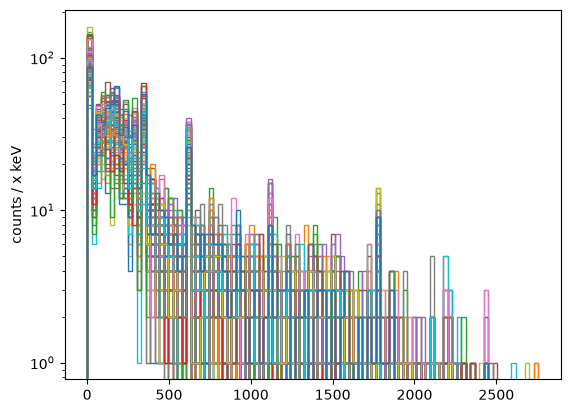

In [25]:
def plot_edep_reboost(detid):
    #data = lh5.read_as(f"stp/{detid}", "out_l200.lh5", "ak", with_units=True)
    data = lh5.read_as(f"stp/{detid}", "out_l200.lh5", "ak", with_units=True)


    charge_collection_eff = reboost.math.functions.piecewise_linear_activeness(
        data.dist_to_surf,
        fccd_in_mm=1,
        dlf=1,
    )
    
    energy = ak.sum(data.edep*charge_collection_eff,axis=-1)

    energy_smeared = reboost.math.stats.gaussian_sample(energy, sigma=1)

    plt.hist(energy_smeared, bins=100, range=(0, 2755), histtype='step', label=detid)

plt.figure() 

for det_name in list(mapping.values())[1:]:
    #print(det_name)
    plot_edep_reboost(det_name)
plt.yscale("log")
plt.ylabel("counts / x keV")
# There are so many detectors that the legend will block out the sun
#plt.legend(ncol=4)

In [26]:
data = lh5.read_as(f"stp/B00091D", "out_l200.lh5", "ak", with_units=True)


In [27]:
data.dist_to_surf

<Array [[0.0147, 0.0147, 0.0118], ..., [...]] type='653 * [var * float64, p...'>